# **Parameter Efficient Fine Tuning (PEFT) with LoRA as adaption method.**

In [2]:
# Importing Libraries and loading datset.

!pip install transformers datasets torch scikit-learn accelerate peft

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_ckpt = "distilbert-base-uncased"
raw_datasets = load_dataset("stanfordnlp/imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
# Instantiate the tokenizer.

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
# Split the training set to create a 10% validation set.

train_valid_split = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

train_dataset = train_valid_split["train"]
eval_dataset = train_valid_split["test"]
test_dataset = tokenized_datasets["test"]

In [4]:
!pip install evaluate scikit-learn
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


In [5]:
!pip install peft

In [6]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [8]:
from peft import LoraConfig, get_peft_model, TaskType

print("Initializing model for PEFT (LoRA)...")
model_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.2,      
    bias="none"
)

model_peft = get_peft_model(model_base, peft_config)
model_peft.print_trainable_parameters()

Initializing model for PEFT (LoRA)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [9]:
from transformers import TrainingArguments

training_args_peft = TrainingArguments(
    output_dir="./results_peft",
    
    # Evaluation & Saving Strategy
    eval_strategy="steps",          # Evaluate mid-epoch to catch peak validation accuracy
    eval_steps=250,                 # Frequent evaluations (tweak based on step count)
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,             # Keep storage clean by saving only the top 2 checkpoints
    
    # Optimization Hyperparameters
    learning_rate=3e-5,             # Lowered for a stabler, longer 10-epoch training run
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,            # Set to your target 10 epochs
    weight_decay=0.1,               # Increased L2 regularization to suppress overfitting
    
    # Learning Rate Schedule
    lr_scheduler_type="cosine",     # Smoothly decays learning rate towards the end
    warmup_ratio=0.1,               # Warmup for the first 10% of total steps
    
    # Early Stopping Support
    load_best_model_at_end=True,    # Automatically roll back to the highest validation score
    metric_for_best_model="accuracy",
    
    # Logging
    logging_dir="./logs_peft",
    logging_steps=50,
    report_to="none"                # Change to "wandb" or "tensorboard" if tracking progress
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [10]:
from transformers import Trainer, EarlyStoppingCallback

trainer_peft = Trainer(
    model=model_peft,
    args=training_args_peft,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Halts training if model degrades
)

print("Starting PEFT (LoRA) Fine-Tuning Training...")
train_result_peft = trainer_peft.train()
print("Training complete! Best model has been loaded.")

Starting PEFT (LoRA) Fine-Tuning Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy
250,1.353033,1.328739,0.728400
500,0.668919,0.637720,0.866400
750,0.628081,0.568816,0.881600
1000,0.525080,0.538138,0.890800
1250,0.569133,0.513553,0.894800
1500,0.483941,0.511000,0.901200
1750,0.535378,0.487921,0.900400
2000,0.510771,0.488682,0.900800
2250,0.470588,0.487334,0.902800
2500,0.443972,0.479291,0.904800


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Training complete! Best model has been loaded.


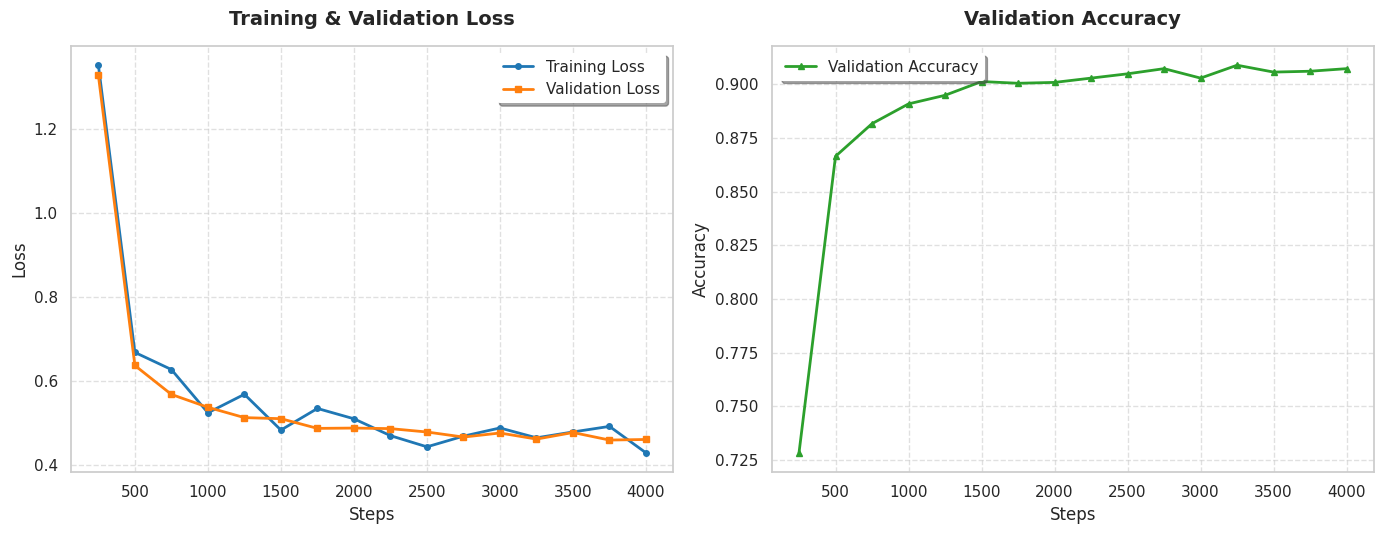

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
steps = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000]
train_loss = [1.353033, 0.668919, 0.628081, 0.525080, 0.569133, 0.483941, 0.535378, 0.510771, 0.470588, 0.443972, 0.469411, 0.488937, 0.465433, 0.479400, 0.492657, 0.429585]
val_loss = [1.328739, 0.637720, 0.568816, 0.538138, 0.513553, 0.511000, 0.487921, 0.488682, 0.487334, 0.479291, 0.467204, 0.476931, 0.462419, 0.478085, 0.460112, 0.461478]
accuracy = [0.728400, 0.866400, 0.881600, 0.890800, 0.894800, 0.901200, 0.900400, 0.900800, 0.902800, 0.904800, 0.907200, 0.902800, 0.908800, 0.905600, 0.906000, 0.907200]

# Set style
sns.set_theme(style="whitegrid")

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot Loss
ax1.plot(steps, train_loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
ax1.plot(steps, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Steps', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
ax2.plot(steps, accuracy, label='Validation Accuracy', color='#2ca02c', linewidth=2, marker='^', markersize=5)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Steps', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
ax2.grid(True, linestyle='--', alpha=0.6)

# Optimize layout
plt.tight_layout()

# Save the plot
plt.show()

In [12]:
# Getting predictions and raw logits.

import numpy as np

prediction_output_peft = trainer_peft.predict(test_dataset)

raw_logits_peft = prediction_output_peft.predictions
y_true_peft = prediction_output_peft.label_ids

y_pred_peft = np.argmax(raw_logits_peft, axis=-1)
exp_logits_peft = np.exp(raw_logits_peft - np.max(raw_logits_peft, axis=-1, keepdims=True))
probabilities_peft = exp_logits_peft / np.sum(exp_logits_peft, axis=-1, keepdims=True)
y_probs_peft = probabilities_peft[:, 1]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [18]:
# Printing accuracy metrics.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_peft = accuracy_score(y_true_peft, y_pred_peft)
precision_peft = precision_score(y_true_peft, y_pred_peft, average='binary')
recall_peft = recall_score(y_true_peft, y_pred_peft, average='binary')
f1_peft = f1_score(y_true_peft, y_pred_peft, average='binary')
roc_auc_peft = roc_auc_score(y_true_peft, y_probs_peft)

print("\n==============================================")
print("         PEFT (LoRA) FINAL PERFORMANCE        ")
print("==============================================")
print(f"Accuracy:  {accuracy_peft:.4f}")
print(f"Precision: {precision_peft:.4f}")
print(f"Recall:    {recall_peft:.4f}")
print(f"F1-Score:  {f1_peft:.4f}")
print(f"ROC-AUC:   {roc_auc_peft:.4f}")
print("=================")


         PEFT (LoRA) FINAL PERFORMANCE        
Accuracy:  0.9091
Precision: 0.8934
Recall:    0.9291
F1-Score:  0.9109
ROC-AUC:   0.9711


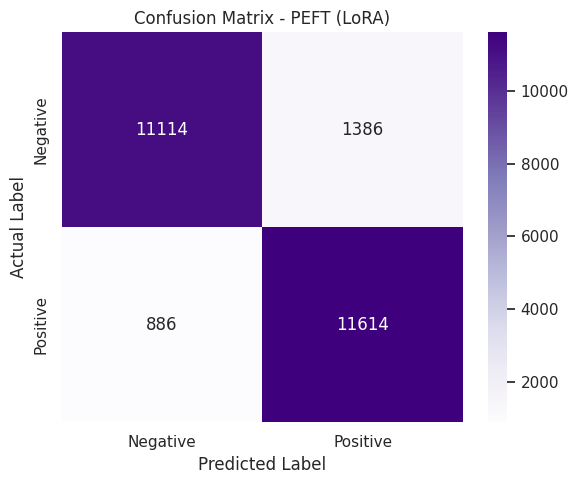

In [14]:
# Plotting confusion matrix and AUC-ROC Curves.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

# 1. Plot and save Confusion Matrix
cm_peft = confusion_matrix(y_true_peft, y_pred_peft)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_peft, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - PEFT (LoRA)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_peft.png', dpi=300)
plt.show()


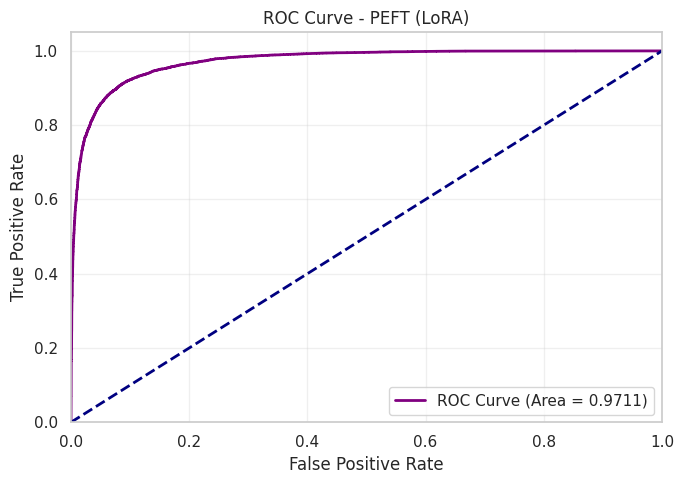

In [15]:
# 2. Plot and save ROC Curve
fpr_peft, tpr_peft, _ = roc_curve(y_true_peft, y_probs_peft)
plt.figure(figsize=(7, 5))
plt.plot(fpr_peft, tpr_peft, color='purple', lw=2, label=f'ROC Curve (Area = {roc_auc_peft:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PEFT (LoRA)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_peft.png', dpi=300)
plt.show()